# Data Annotation: CIELAB Color Labeling

This notebook covers:
- Extracting the ground truth CIELAB color from the annotated images

# Setup

In [2]:
import glob
import os

from PIL import Image
from skimage.color import rgb2lab, lab2rgb
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Paths

In [ ]:
BASE = os.path.abspath('../data')
DATA = os.path.join(BASE, 'processed')
RAW  = os.path.join(BASE, 'product_metadata')
IMGS = os.path.join(BASE, 'img', 'original')
IMGS_GT = os.path.join(BASE, 'img', 'groundtruth')

# Annotation Status

I was not able to get the groundtruth color swatch from 13 images because they were transparent/white images with no visible color content (essentially blank when viewed).

Thus, 209 out of the 222 sampled images will have a ground truth color value. This is still comfortably above the minimum sample size of 188, so the sample remains statistically valid.

Swatches were created on April 11 and April 12, 2026. Images that remain unmodified from April 9 (the date they were copied to the groundtruth folder) did not receive a swatch. The color_swatch column uses file modification dates to encode this: 1 = swatch created, 0 = unannotatable (modified date April 9), None = not part of the annotation sample.

In [22]:
from collections import Counter
from datetime import date

IMGS_GT = os.path.join(os.path.abspath('../data'), 'img', 'groundtruth')

files = [f for f in os.listdir(IMGS_GT) if os.path.isfile(os.path.join(IMGS_GT, f))]
print(f"Total files: {len(files)}")

dates = Counter(
    date.fromtimestamp(os.path.getmtime(os.path.join(IMGS_GT, f))).isoformat()
    for f in files
)
for d, count in sorted(dates.items()):
    print(f"{d}: {count}")

Total files: 222
2026-04-09: 13
2026-04-11: 159
2026-04-12: 50


In [ ]:

metadata = pd.read_csv(f'{DATA}/products_with_images.csv', index_col=0)

IMGS_GT = os.path.join(os.path.abspath('../data'), 'img', 'groundtruth')

def get_swatch_status(img_name):
    """
    Determine whether a ground truth color swatch exists for an image.

    Parameters
    ----------
    img_name : str
        Filename of the product image (e.g. 'lipstick__brand__product__shade.jpg').

    Returns
    -------
    int or None
        1 if a corresponding file exists in the groundtruth folder and was annotated
          (modified after 2026-04-09).
        0 if the file exists but could not be annotated (modified on 2026-04-09,
          e.g. transparent/blank images or images without visible lipstick color).
        None if the image was not part of the annotation sample.
    """
    
    if not isinstance(img_name, str) or '.' not in img_name:
        return None
    stem = os.path.splitext(img_name)[0]
    for f in os.listdir(IMGS_GT):
        if os.path.splitext(f)[0] == stem:
            mod_date = date.fromtimestamp(os.path.getmtime(os.path.join(IMGS_GT, f))).isoformat()
            if mod_date == '2026-04-09':
                return 0
            return 1
    return None

metadata['color_swatch'] = metadata['img_name'].apply(get_swatch_status)
print(metadata['color_swatch'].value_counts(dropna=False))

color_swatch
NaN    10421
1.0      209
0.0       13
Name: count, dtype: int64


In [24]:
metadata.to_csv(f'{DATA}/products_with_images.csv')

# Ground Truth CIELAB Color Value

CIELAB (L*a*b*) is a perceptually uniform color space where distances between colors correspond to how different they appear to the human eye. Unlike RGB, equal numerical differences in CIELAB correspond to roughly equal perceptual differences, making it well-suited for comparing lipstick colors across brands and products.

Ground truth CIELAB values were extracted by manually cropping each sampled product image to isolate the lipstick color swatch: the area showing the actual pigment rather than the packaging. The mean L*, a*, and b* values across all pixels in the cropped region were then computed as the ground truth color for that product. This approach assumes the cropped swatch is representative of the color the product delivers, which holds well for flat swatch images but may be less precise for textured or glossy finishes.

In [5]:
metadata = pd.read_csv(f'{DATA}/products_with_images.csv', index_col=0)
metadata.head()

,id,category,joined,brand,product,shade,img_url,shade_description_original,validation,img_name,img_size,img_height,img_width,img_color_distribution,img_corrupted,sampled,color_swatch
0,lipstick__100_pure__fruit_pigmented_cocoa_butt...,lipstick,100% pure fruit pigmented cocoa butter matte l...,100% pure,fruit pigmented cocoa butter matte lipstick,blood orange,https://www.100percentpure.com/cdn/shop/files/...,classic brick red,True,lipstick__100_pure__fruit_pigmented_cocoa_butt...,433563.0,840.0,840.0,"[1607453, 165, 236, 287, 406, 487, 814, 1055, ...",False,0,NaN
1,lipstick__100_pure__fruit_pigmented_cocoa_butt...,lipstick,100% pure fruit pigmented cocoa butter matte l...,100% pure,fruit pigmented cocoa butter matte lipstick,cacti,https://www.100percentpure.com/cdn/shop/files/...,cool-toned sepia-brown,True,lipstick__100_pure__fruit_pigmented_cocoa_butt...,80428.0,1260.0,1260.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",False,0,NaN
2,lipstick__100_pure__fruit_pigmented_cocoa_butt...,lipstick,100% pure fruit pigmented cocoa butter matte l...,100% pure,fruit pigmented cocoa butter matte lipstick,mirage,https://www.100percentpure.com/cdn/shop/files/...,cool deep dusty pink,True,lipstick__100_pure__fruit_pigmented_cocoa_butt...,80444.0,1260.0,1260.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",False,0,NaN
3,lipstick__100_pure__fruit_pigmented_cocoa_butt...,lipstick,100% pure fruit pigmented cocoa butter matte l...,100% pure,fruit pigmented cocoa butter matte lipstick,plume pink,https://www.100percentpure.com/cdn/shop/files/...,nude pink mauve,True,lipstick__100_pure__fruit_pigmented_cocoa_butt...,56924.0,1005.0,1005.0,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",False,0,NaN
4,lipstick__100_pure__fruit_pigmented_cocoa_butt...,lipstick,100% pure fruit pigmented cocoa butter matte l...,100% pure,fruit pigmented cocoa butter matte lipstick,winecup,https://www.100percentpure.com/cdn/shop/files/...,cool-toned antique berry,True,404,NaN,NaN,NaN,NaN,False,0,NaN


In [17]:
import warnings

# extract CIELAB from swatches and save it metadata
def extract_cielab(img_name):
    '''
  Extract the mean CIELAB color from a cropped ground truth swatch image.

  Parameters
  ----------
    img_name : str
    Filename of the product image (e.g. 'lipstick__brand__product__shade.jpg').
    The function looks for a file with the same stem (any extension) in IMGS_GT.

  Returns
  -------
    numpy.ndarray or None
    Array of shape (3,) with mean [L, a, b] values across all pixels.
    None if no matching file is found in the groundtruth folder.

    '''

    stem = os.path.splitext(img_name)[0]
    matches = glob.glob(os.path.join(IMGS_GT, stem + '.*'))
    if not matches:
        return None
    swatch = cv2.imread(matches[0])
    swatch = cv2.cvtColor(swatch, cv2.COLOR_BGR2RGB) / 255.0
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        img_lab = rgb2lab(swatch)
    return img_lab.mean(axis=0).mean(axis=0)

In [18]:
# apply function and store in metadata
metadata['ground_truth_CIELAB'] = None
mask = metadata['color_swatch'] == 1
metadata.loc[mask, 'ground_truth_CIELAB'] = metadata.loc[mask, 'img_name'].apply(extract_cielab)

In [20]:
metadata.ground_truth_CIELAB.info()

<class 'pandas.core.series.Series'>
Index: 10643 entries, 0 to 10642
Series name: ground_truth_CIELAB
Non-Null Count  Dtype 
--------------  ----- 
209 non-null    object
dtypes: object(1)
memory usage: 166.3+ KB


In [ ]:
metadata.to_csv(f'{DATA}/products_with_images.csv')

# Ground Truth Color Space Coverage

The figure below showcases the ground truth colors from the 209 swatches in the sample. Groups like `black`, `blue_green`, `brick`, and `gold_bronze` are visually cohesive. In contrast, the variation in the larger groups is striking. `berry_plum` contains everything from deep burgundy to bright pink and even a navy blue. `brown` spans from pale nude to near-black. `orange` and `peach` overlap considerably. This reflects a well-known challenge in cosmetics: brand color names (e.g. "cranberry red", "wine", "plum") are marketing descriptors, not perceptual categories, and offer little reliable signal about the actual color a product delivers.

The ground truth sample covers all 18 color groups, with larger groups like `red`, `rose`, `berry_plum`, and `brown` contributing the most swatches proportionally. Smaller groups (`silver_gray`, `blue_green`, `brick`) meet the minimum floor of 5 samples each, ensuring all color families are represented in the validation set.

Overall, the ground truth sample of 209 swatches shows strong coverage of the lipstick color space. The mean pairwise Delta E (ΔE) of 30.54 (median 27.34) indicates that swatches are, on average, far apart in perceptual color space and well above the just-noticeable difference threshold of ΔE = 2 used to calculate the target sample size. Standard deviations across CIELAB channels (L: 13.59, a: 15.46, b: 13.07) confirm broad spread along all three axes, with the highest variation along the a axis (red-green), as expected for a lipstick dataset. Together, these metrics suggest the stratified sampling strategy successfully captured the diversity of colors available in the market.

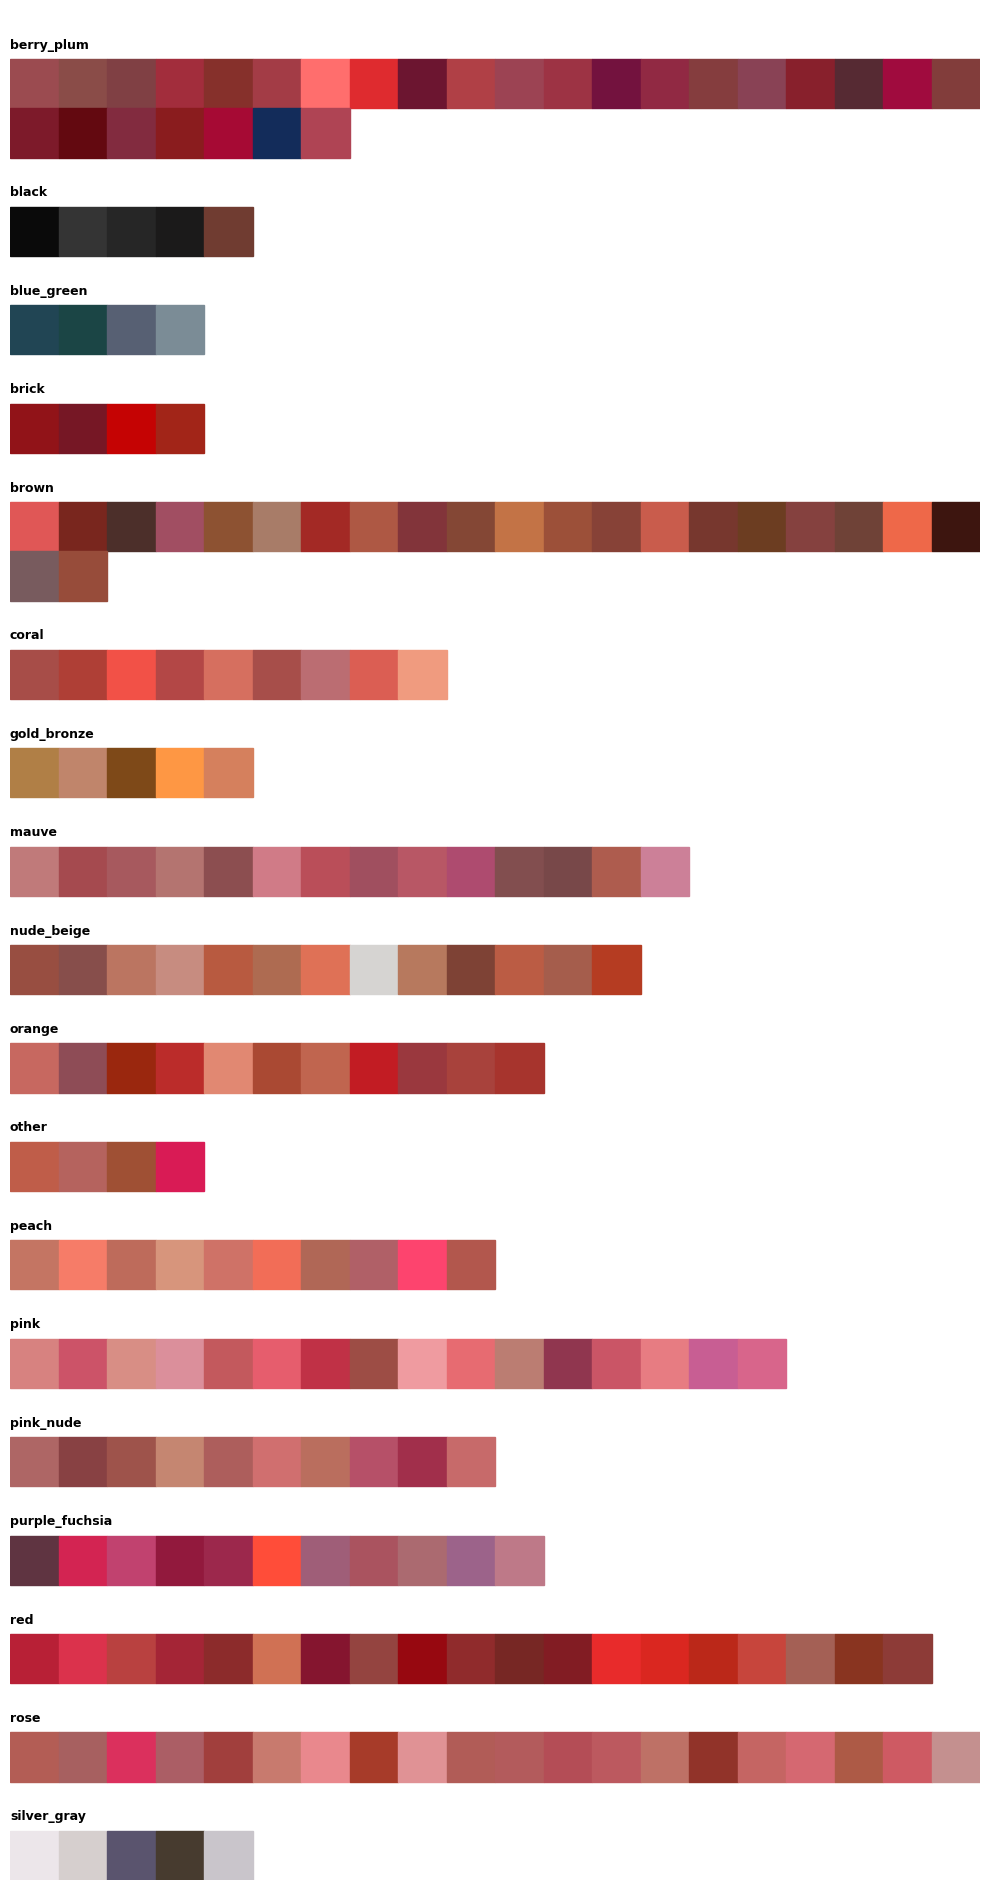

In [32]:
from skimage.color import lab2rgb
import matplotlib.patches as patches

def cielab_to_rgb(lab_array):
    lab = np.array(lab_array).reshape(1, 1, 3)
    return np.clip(lab2rgb(lab).reshape(3), 0, 1)

gt = metadata[metadata['color_swatch'] == 1].copy()
gt['rgb'] = gt['ground_truth_CIELAB'].apply(cielab_to_rgb)

COLS = 20
TILE = 1
groups = sorted(gt.groupby('color_group'), key=lambda x: x[0])

total_rows = sum(1 + int(np.ceil(len(g) / COLS)) for _, g in groups)
fig, ax = plt.subplots(figsize=(COLS * 0.5, total_rows * 0.5))
ax.set_xlim(0, COLS)
ax.set_ylim(total_rows, 0)
ax.axis('off')

y = 0
for group_name, group_df in groups:
    ax.text(0, y + 0.85, group_name, fontsize=9, fontweight='bold', va='bottom')
    y += 1
    for i, (_, row) in enumerate(group_df.iterrows()):
        col = i % COLS
        row_idx = i // COLS
        rect = patches.Rectangle((col, y + row_idx), TILE, TILE, color=row['rgb'])
        ax.add_patch(rect)
    y += int(np.ceil(len(group_df) / COLS))

plt.tight_layout()
plt.show()

In [33]:
from scipy.spatial.distance import pdist

gt = metadata[metadata['color_swatch'] == 1].copy()
lab_values = np.stack(gt['ground_truth_CIELAB'].values)

# Std per channel
l_std, a_std, b_std = lab_values.std(axis=0)
print(f"L std: {l_std:.2f} | a std: {a_std:.2f} | b std: {b_std:.2f}")

# Mean pairwise ΔE (Euclidean distance in CIELAB)
delta_e = pdist(lab_values, metric='euclidean')
print(f"Mean pairwise ΔE: {delta_e.mean():.2f}")
print(f"Median pairwise ΔE: {np.median(delta_e):.2f}")

L std: 13.59 | a std: 15.46 | b std: 13.07
Mean pairwise ΔE: 30.54
Median pairwise ΔE: 27.34
